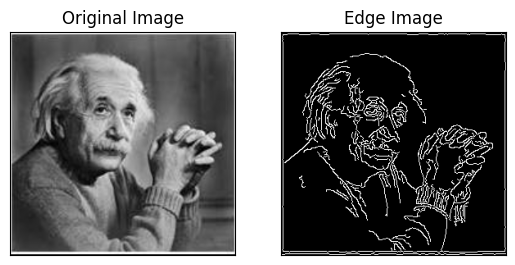

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread("/content/einstein.jpg",0)
edges = cv2.Canny(img,100,200)
plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image')
plt.xticks([])
plt.yticks([])
plt.subplot(122)
plt.imshow(edges,cmap ='gray')
plt.title('Edge Image')
plt.xticks([]),
plt.yticks([])
plt.show()

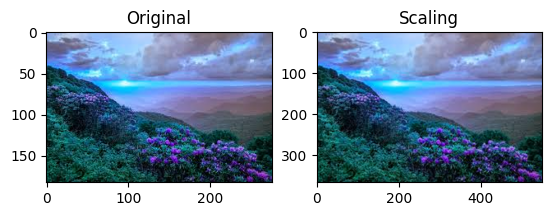

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('/content/j.jpeg')
#res = cv2.resize(img,None,fx=2, fy=2, interpolation = cv2.INTER_CUBIC)
height, width = img.shape[:2]
res = cv2.resize(img,(2*width, 2*height), interpolation = cv2.INTER_CUBIC)
plt.subplot(121),plt.imshow(img),plt.title('Original')
#plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(res),plt.title('Scaling')
#plt.xticks([]), plt.yticks([])
plt.show()

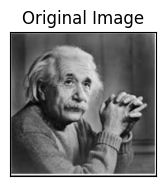

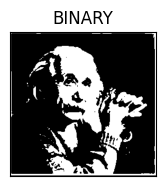

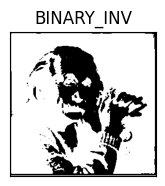

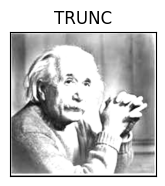

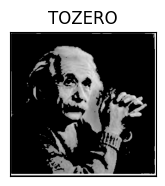

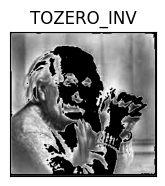

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('/content/einstein.jpg',0)
ret,thresh1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO_INV)
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
for i in range(6):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
  plt.show()

In [13]:
!pip install opencv-python-headless matplotlib numpy scikit-image -q

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure
from google.colab.patches import cv2_imshow
def show(images, titles, cmap_list=None, figsize=(16, 4)):
    """Helper: display multiple images side by side."""
    n = len(images)
    if cmap_list is None:
       cmap_list = ['gray'] * n
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title, cmap in zip(axes, images, titles, cmap_list):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

img_gray = cv2.cvtColor(
cv2.resize(
np.array(data.camera(), dtype=np.uint8),
(512, 512)
), cv2.COLOR_GRAY2BGR
)
img_gray = cv2.cvtColor(img_gray, cv2.COLOR_BGR2GRAY)
print(" Setup complete. Image shape:", img_gray.shape)

 Setup complete. Image shape: (512, 512)


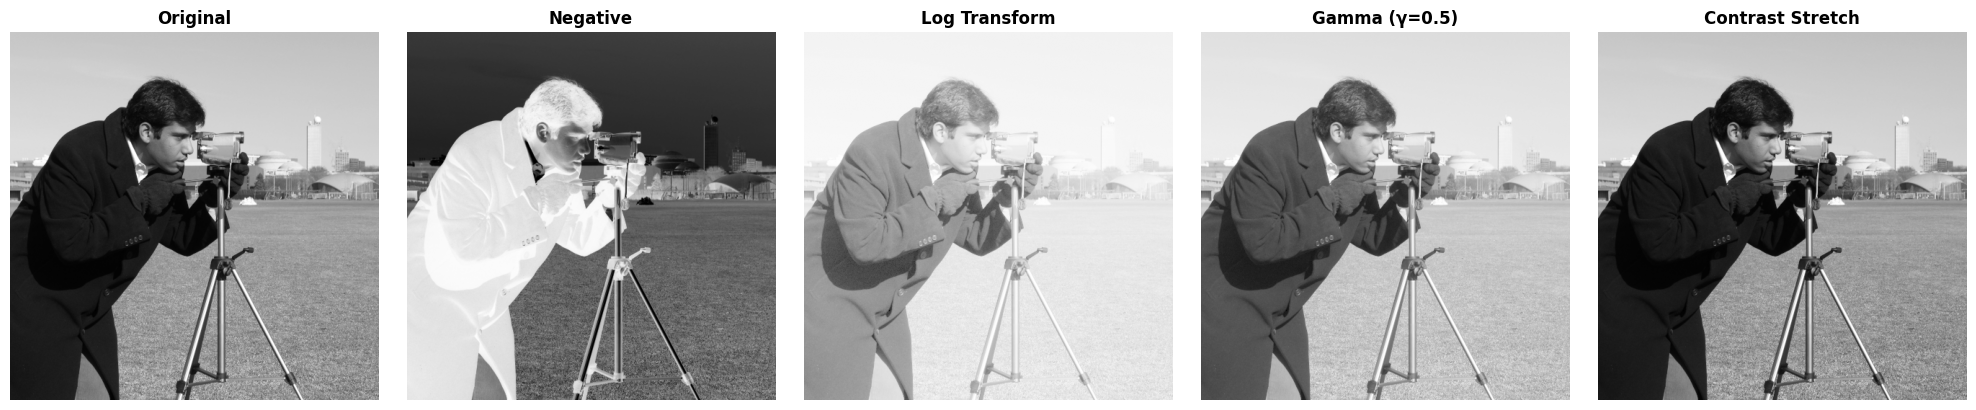

 Intensity Transformations complete.


In [28]:
def intensity_transformations(img):
  img = img.astype(np.float64)
  L = 256 # gray levels
  # 1. Image Negative
  negative = L - 1 - img
  # 2. Log Transformation: s = c * log(1 + r)
  c = (L - 1) / np.log(1 + np.max(img))
  log_img = c * np.log(1 + img)
  # 3. Power-Law (Gamma) Transformation: s = c * r^gamma
  gamma = 0.5 # <1 brightens, >1 darkens
  c = 1.0
  gamma_img = c * np.power(img / 255.0, gamma) * 255
  # 4. Contrast Stretching: linear stretch to [0, 255]
  r_min, r_max = img.min(), img.max()
  contrast = (img - r_min) / (r_max - r_min) * 255
  images = [
    img.astype(np.uint8),
    negative.astype(np.uint8),
    log_img.astype(np.uint8),
    gamma_img.astype(np.uint8),
    contrast.astype(np.uint8)
  ]
  titles = ['Original', 'Negative', 'Log Transform',
            f'Gamma (γ={gamma})', 'Contrast Stretch']
  show(images, titles, figsize=(20, 4))
  print(" Intensity Transformations complete.")
intensity_transformations(img_gray)

 Histogram Processing complete.


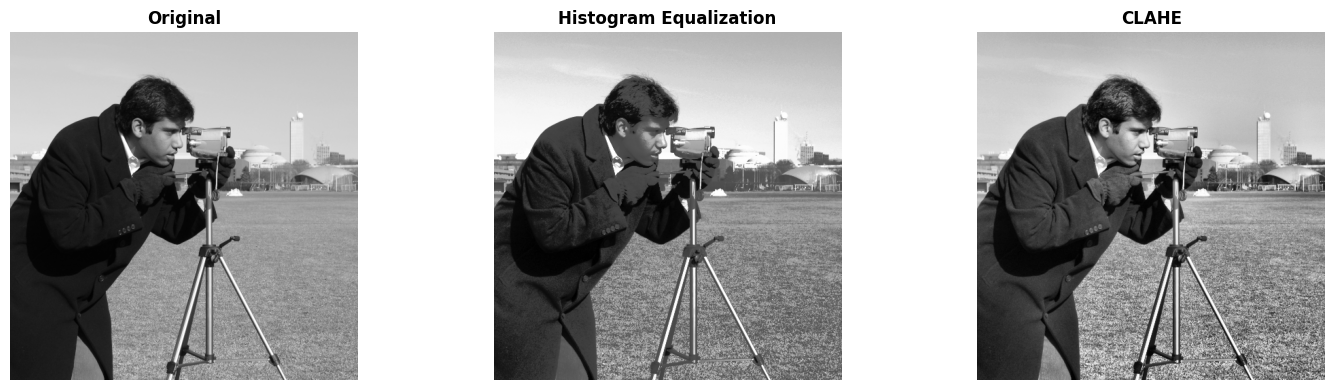

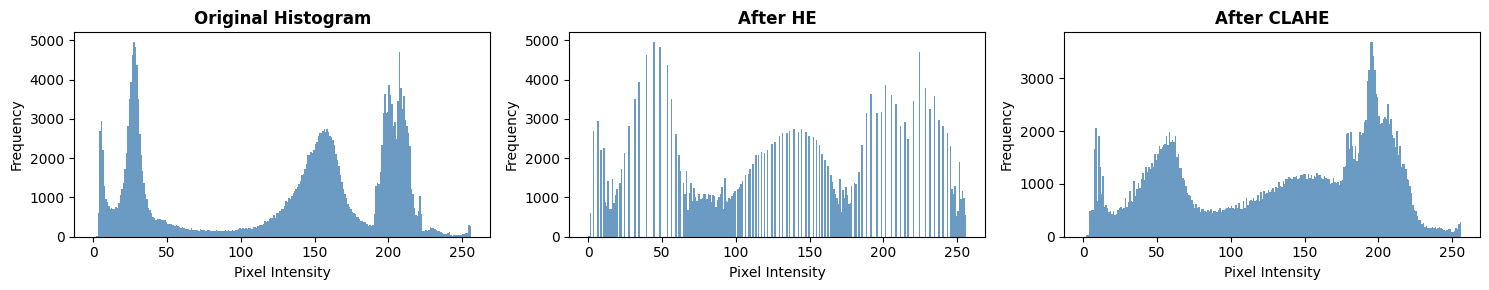

In [30]:
def histogram_processing(img):
  # Standard Histogram Equalization
  hist_eq = cv2.equalizeHist(img)
  # CLAHE (Contrast Limited Adaptive Histogram Equalization)
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
  clahe_img = clahe.apply(img)
  # Plot images
  show(
      [img, hist_eq, clahe_img],
      ['Original', 'Histogram Equalization', 'CLAHE'],
      figsize=(15, 4)
  )
  # Plot histograms
  fig, axes = plt.subplots(1, 3, figsize=(15, 3))
  for ax, image, title in zip(axes,
                                  [img, hist_eq, clahe_img],
                                  ['Original Histogram', 'After HE', 'After CLAHE']):
      ax.hist(image.ravel(), bins=256, range=(0, 256), color='steelblue', alpha=0.8)
      ax.set_title(title, fontweight='bold')
      ax.set_xlabel('Pixel Intensity')
      ax.set_ylabel('Frequency')
  plt.tight_layout()
  plt.show()
print(" Histogram Processing complete.")
histogram_processing(img_gray)

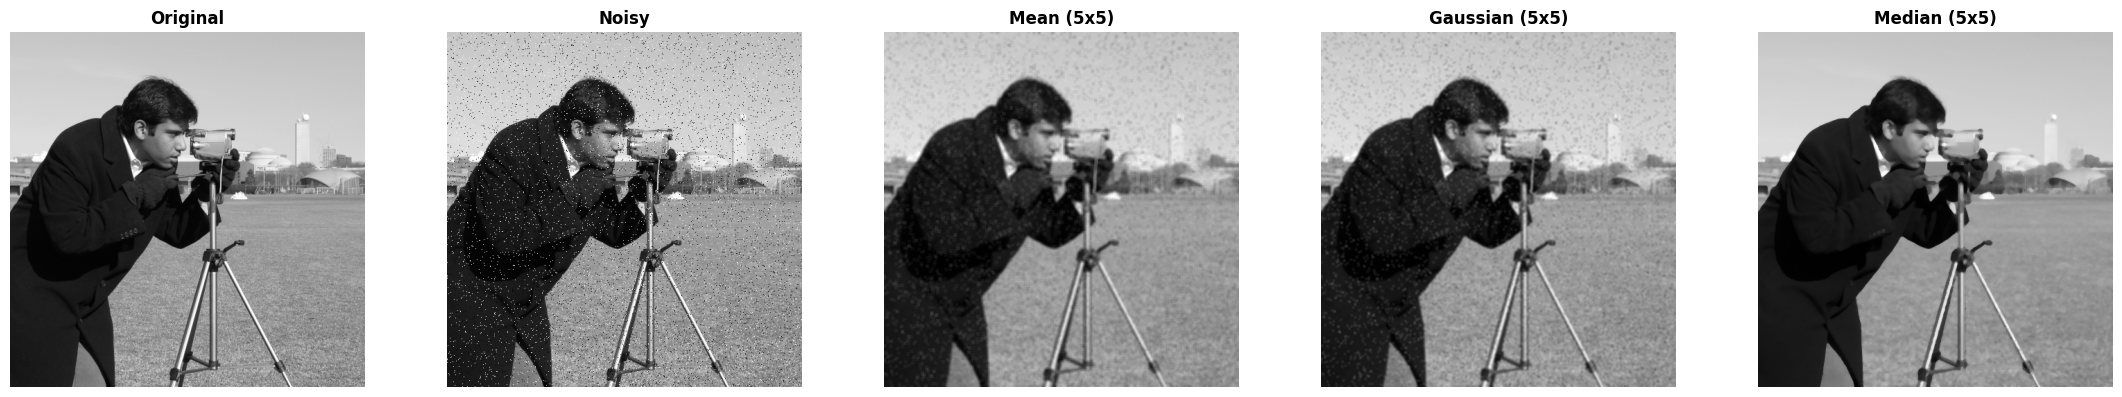

 Smoothing Filters complete.


In [29]:
def smoothing_filters(img):
  # Add salt-and-pepper noise for demonstration
  noisy = img.copy()
  num_salt = int(0.02 * img.size)
  coords = [np.random.randint(0, d, num_salt) for d in img.shape]
  noisy[tuple(coords)] = 255
  coords = [np.random.randint(0, d, num_salt) for d in img.shape]
  noisy[tuple(coords)] = 0
  ksize = 5 # kernel size

  # 1. Mean (Averaging) Filter
  mean_f = cv2.blur(noisy, (ksize, ksize))
  # 2. Gaussian Filter
  gauss_f = cv2.GaussianBlur(noisy, (ksize, ksize), sigmaX=1.5)
  # 3. Median Filter (best for salt-and-pepper)
  median_f = cv2.medianBlur(noisy, ksize)
  show(
    [img, noisy, mean_f, gauss_f, median_f],
    ['Original', 'Noisy', f'Mean ({ksize}x{ksize})',
    f'Gaussian ({ksize}x{ksize})', f'Median ({ksize}x{ksize})'],
    figsize=(22, 4)
  )
  print(" Smoothing Filters complete.")
smoothing_filters(img_gray)